In [1]:
import pandas as pd
import numpy as np

In [4]:
# loading the dataset:
df = pd.read_csv("estimated_salary.csv")

In [6]:
df.shape

(16, 3)

In [10]:
df.info()
# no null values present.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              16 non-null     int64 
 1   EstimatedSalary  16 non-null     int64 
 2   Buy              16 non-null     object
dtypes: int64(2), object(1)
memory usage: 516.0+ bytes


In [16]:
X = df.iloc[:, :-1] #input features
y = df.iloc[:, -1] #target variable  

In [18]:
# the target variable is categorical; hence using map().
y = y.map({"No" : 0, "Yes" : 1})
# No is replaced with 0 and Yes with 1.

## Splitting the data:

In [19]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

## Scaling using standard scaler 

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

fit - learns mean and standard deviation from X_train,


transform - uses those values to scale the data.

In [23]:
from sklearn.neighbors import KNeighborsClassifier

# K Tuning:

In [48]:
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9]
}

grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best K:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

c:\Users\imsra\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best K: {'n_neighbors': 3}
Best Accuracy: 1.0


In [53]:
knn = KNeighborsClassifier(n_neighbors=3)
#best value of k that we got by tuning

### Note:- 
When KNN gets a new data point, it looks at its 3 nearest data points and takes the majority vote.

In [28]:
# training the model:
knn.fit(X_train, y_train)

ValueError: Input y contains NaN.

#### correcting the error:

In [29]:
print(X_train.shape)
print(y_train.shape)
print(type(X_train))
print(type(y_train))

(12, 2)
(12,)
<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>


In [30]:
print(y_train)

13   NaN
11   NaN
8    NaN
9    NaN
2    NaN
15   NaN
4    NaN
7    NaN
10   NaN
12   NaN
3    NaN
6    NaN
Name: Buy, dtype: float64


### redoing the train-test split:

In [31]:
print(df["Buy"].unique())

['No' 'Yes']


In [32]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [33]:
y = y.map({"No": 0, "Yes": 1})
print(y)

0     0
1     0
2     0
3     0
4     0
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
Name: Buy, dtype: int64


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

### Scaling the values

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## making predictions

In [37]:
y_pred = knn.predict(X_test)

In [39]:
print(y_pred)
print(y_test.values)

[0 1 1 1]
[0 1 1 1]


In [40]:
# accuracy score:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 1.0


#### note:- test set has only 4 observations, so getting 100% here doesn't necessarily mean the model will always be 100% accurate on new data.

In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precision: 1.0
Recall: 1.0
F1-Score: 1.0


### Classification Report:

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [41]:
from sklearn.metrics import confusion_matrix

In [42]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1 0]
 [0 3]]


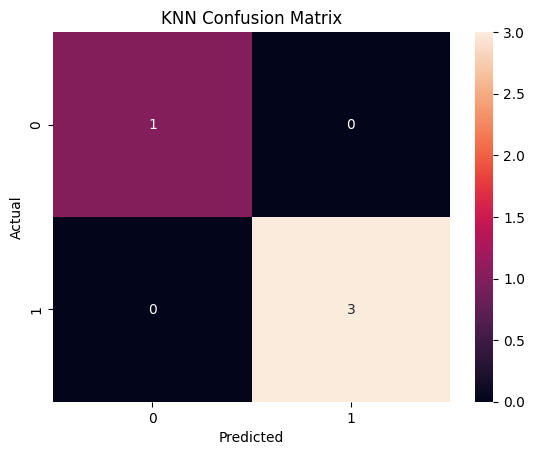

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

## insights:
1. actual NO , predited NO = 1.
2. actual NO , predicted YES=0.
1. actual YES , predited NO = 0.
1. actual YES , predited YES = 1.

In [45]:
new_person = [[37, 48000]]

new_person_scaled = scaler.transform(new_person)

prediction = knn.predict(new_person_scaled)

print(prediction)

[1]


c:\Users\imsra\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
